**Aggregation Model**

In [2]:
## DATA AND PACKAGE IMPORT 

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from types import SimpleNamespace

## import data from particle concentration, backscatter, fluorescence
part_conc_490 = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="4903659_binned_small_removed").iloc[:, 1:]
part_conc_699 = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="6990636_binned_small_removed").iloc[:, 1:]

'''''

bbp_490 = pd.read_excel("BBP_binned.xlsx", sheet_name="4903659")
bbp_699 = pd.read_excel("BBP_binned.xlsx", sheet_name="6990636")

chla_fluor_490 = pd.read_excel("Chl_fluor_binned.xlsx", sheet_name="4903659")
chla_fluor_699 = pd.read_excel("Chl_fluor_binned.xlsx", sheet_name="6990636")

'''

temp_490 = pd.read_excel("Temp_binned.xlsx", sheet_name="4903659")
temp_699 = pd.read_excel("Temp_binned.xlsx", sheet_name="6990636")

sal_490 = pd.read_excel("Sal_binned.xlsx", sheet_name="4903659")
sal_699 = pd.read_excel("Sal_binned.xlsx", sheet_name="6990636")

# define depth array, time array (profiles)
depth = part_conc_490["depth_bin"].iloc[:60]
time_490 = pd.Series(range(1, 45))
time_699 = pd.Series(range(1, 78))            # probably won't use all of these profiles
#size_classes = part_conc_490.columns.to_numpy()[1:]
sizes = np.array([102,128,161,203,256,323,406,512,645,813,1020,1290,1630,2050,2580])

In [3]:
## SEPARATING FLOAT 490 PROFILES INTO INDIVIDUAL UVP6 DATAFRAMES 
# this does not contain backscatter or fluorescence yet

# Create container object
f490 = SimpleNamespace()

# Identify blank rows (all NaN) and get indices
blank_rows = part_conc_490.isna().all(axis=1)
split_points = blank_rows[blank_rows].index.tolist()

# Add start and end boundaries
split_points = [-1] + split_points + [len(part_conc_490)]

skip_numbers = {13, 19}

section_number = 1

for i in range(len(split_points) - 1):
    start = split_points[i] + 1
    end = split_points[i + 1]

    # Extract the block
    block = part_conc_490.iloc[start:end].reset_index(drop=True)

    #block["bbp"] = bbp_490.iloc[:len(block), section_number - 1].values
    #block["chla"] = chla_fluor_490.iloc[:len(block), section_number - 1].values

# Skip truly empty blocks
    if len(block) == 0:
        continue
    
# Skip numbers before assigning
    while section_number in skip_numbers:
        section_number += 1

    attr_name = f"p{section_number}"
    setattr(f490, attr_name, block)

    section_number += 1

# Export an individual profile here (in case one needs checking!)
#f490.p7.to_excel("f490.p7.xlsx", index=False)




## tada, doing the same with 6990636 
# this does not contain backscatter or fluorescence yet

# Create container object
f699 = SimpleNamespace()

# Identify blank rows (all NaN) and get indices
blank_rows = part_conc_699.isna().all(axis=1)
split_points = blank_rows[blank_rows].index.tolist()

# Add start and end boundaries
split_points = [-1] + split_points + [len(part_conc_699)]

skip_numbers = {4, 17, 29, 53, 72}   # works too 11/6

section_number = 1

for i in range(len(split_points) - 1):
    start = split_points[i] + 1
    end = split_points[i + 1]

    # Extract the block
    block = part_conc_699.iloc[start:end].reset_index(drop=True)

    #block["bbp"] = bbp_490.iloc[:len(block), section_number - 1].values
    #block["chla"] = chla_fluor_490.iloc[:len(block), section_number - 1].values

# Skip truly empty blocks
    if len(block) == 0:
        continue
    
# Skip numbers before assigning
    while section_number in skip_numbers:
        section_number += 1

    attr_name = f"p{section_number}"
    setattr(f699, attr_name, block)

    section_number += 1

# Export an individual profile here (in case one needs checking!)
# f699.p8.to_excel("f699.p8.xlsx", index=False)


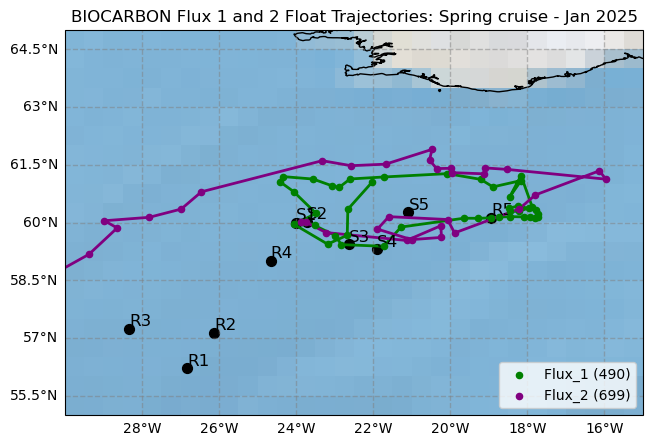

'"\n# Plotting particle concentration data with time\nfig, ax = plt.subplots()\n\n# Particle size 102 data for 490\n# time = (float numbers/dates)\n# y = (data from all profiles for f490)\n\n# Create figure and axes\nfig, ax = plt.subplots()\n\n# Plot the data\nax.plot(x, y, marker=\'o\')\nax.set_xlabel("X values")\nax.set_ylabel("Y values")\nax.set_title("Simple Line Plot")\nax.grid(True)\nplt.show()\n\n'

In [21]:
## Creating Figures for Presentation

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Argo float trajectories figure

float_data = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="UVP_Float_Data")
lat = float_data.loc[:,"latitude"]
lon = float_data.loc[:,"longitude"]
lat.drop_duplicates(inplace = True), lon.drop_duplicates(inplace = True)

# index of first value of 699 is 44
lat_490 = lat[:44]
lon_490 = lon[:44]
lat_699 = lat[44:]
lon_699 = lon[44:]

# plotting on map

# Create a figure with a map projection
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.OCEAN) #facecolor='lightblue')
ax.stock_img()

gl = ax.gridlines(draw_labels=True,
                  linewidth=1,
                  color='gray',
                  alpha=0.5,
                  linestyle='--')

gl.top_labels = False
gl.right_labels = False

s1_lat = 60.00016
s1_lon = -24.0004
s2_lat = 60.01922
s2_lon = -23.7194 
s3_lat = 59.43715
s3_lon = -22.6379 
s4_lat = 59.30469
s4_lon = -21.9108 
s5_lat = 60.26593
s5_lon = -21.0875

r1_lat = 56.21604
r1_lon = -26.8302
r2_lat = 57.12564
r2_lon = -26.1376
r3_lat = 57.23220
r3_lon = -28.3443
r4_lat = 59.01343
r4_lon = -24.6674 
r5_lat = 60.12009
r5_lon = -18.9309


# Plot the points
ax.scatter(lon_490, lat_490, color='green', s=20, label="Flux_1 (490)", transform=ccrs.PlateCarree(), zorder=5)
ax.scatter(lon_699, lat_699, color='purple', s=20, label="Flux_2 (699)", transform=ccrs.PlateCarree(), zorder=5)

ax.legend(loc='lower right')

ax.scatter(s1_lon, s1_lat, color='black', s=50, label="S1", transform=ccrs.PlateCarree())
ax.scatter(s2_lon, s2_lat, color='black', s=50, label="S2", transform=ccrs.PlateCarree())
ax.scatter(s3_lon, s3_lat, color='black', s=50, label="S3", transform=ccrs.PlateCarree())
ax.scatter(s4_lon, s4_lat, color='black', s=50, label="S4", transform=ccrs.PlateCarree())
ax.scatter(s5_lon, s5_lat, color='black', s=50, label="S5", transform=ccrs.PlateCarree())

ax.scatter(r1_lon, r1_lat, color='black', s=50, label="R1", transform=ccrs.PlateCarree())
ax.scatter(r2_lon, r2_lat, color='black', s=50, label="R2", transform=ccrs.PlateCarree())
ax.scatter(r3_lon, r3_lat, color='black', s=50, label="R3", transform=ccrs.PlateCarree())
ax.scatter(r4_lon, r4_lat, color='black', s=50, label="R4", transform=ccrs.PlateCarree())
ax.scatter(r5_lon, r5_lat, color='black', s=50, label="R5", transform=ccrs.PlateCarree())


# Draw lines connecting points
ax.plot(lon_490, lat_490, color='green', linewidth=2, transform=ccrs.PlateCarree())
ax.plot(lon_699, lat_699, color='purple', linewidth=2, transform=ccrs.PlateCarree())

# Set extent (optional: zoom to data)
ax.set_extent([
    -30, -15,
    55, 65
])

ax.text(s1_lon, s1_lat, "S1", fontsize=12, ha='left', va='bottom')
ax.text(s2_lon, s2_lat, "S2", fontsize=12, ha='left', va='bottom')
ax.text(s3_lon, s3_lat, "S3", fontsize=12, ha='left', va='bottom')
ax.text(s4_lon, s4_lat, "S4", fontsize=12, ha='left', va='bottom')
ax.text(s5_lon, s5_lat, "S5", fontsize=12, ha='left', va='bottom')
ax.text(r1_lon, r1_lat, "R1", fontsize=12, ha='left', va='bottom')
ax.text(r2_lon, r2_lat, "R2", fontsize=12, ha='left', va='bottom')
ax.text(r3_lon, r3_lat, "R3", fontsize=12, ha='left', va='bottom')
ax.text(r4_lon, r4_lat, "R4", fontsize=12, ha='left', va='bottom')
ax.text(r5_lon, r5_lat, "R5", fontsize=12, ha='left', va='bottom')


plt.title("BIOCARBON Flux 1 and 2 Float Trajectories: Spring cruise - Jan 2025")
plt.show()
                           
# lost my graph for the powerpoint - rewrite code if needed?

""""
# Plotting particle concentration data with time
fig, ax = plt.subplots()

# Particle size 102 data for 490
# time = (float numbers/dates)
# y = (data from all profiles for f490)

# Create figure and axes
fig, ax = plt.subplots()

# Plot the data
ax.plot(x, y, marker='o')
ax.set_xlabel("X values")
ax.set_ylabel("Y values")
ax.set_title("Simple Line Plot")
ax.grid(True)
plt.show()

"""

C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData

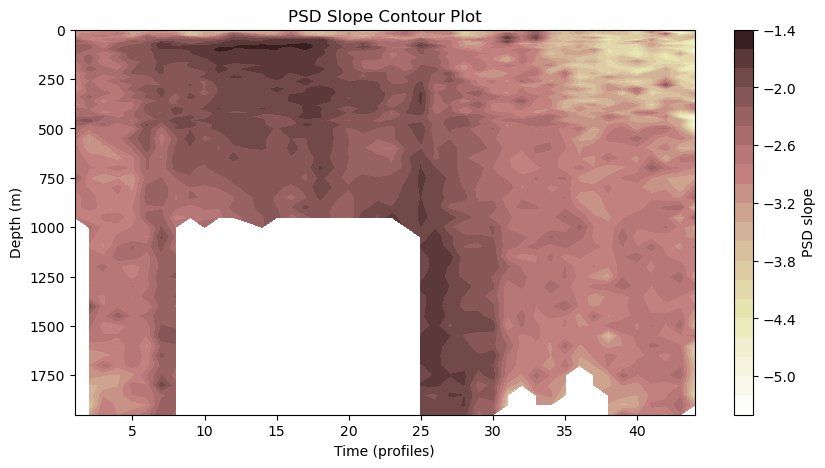

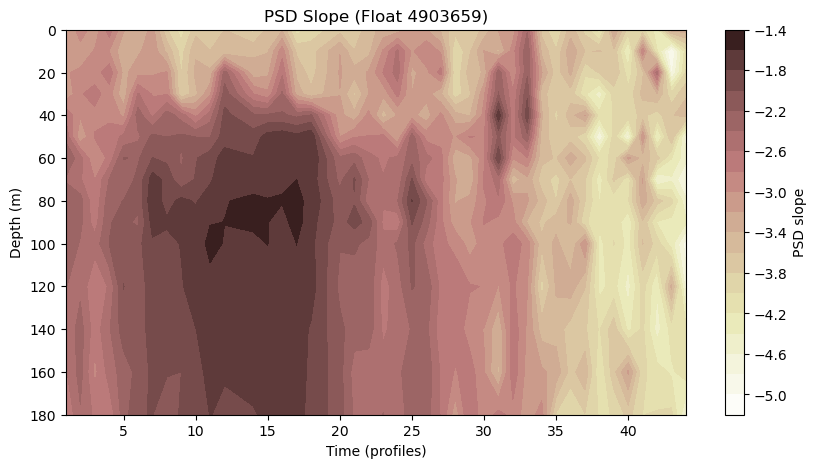

In [3]:
# BIOCARBON playing around
 

# # define parameters of particle size class, fluor, backscatter (maybe do a backscatter POC relationship curve conversion?), eventually turbulence


# input equations for particle dynamics - two size class approach?

# what float profiles match closest with the station locations?

# calculate PSD for each depth across size bins

def psd_slope(sizes, concentrations, use_cumulative=False):
    """
    Calculate PSD slope in log-log space.
    """

    import pandas as pd

    # Convert to pandas Series
    sizes = pd.Series(sizes).reset_index(drop=True)
    concentrations = pd.Series(concentrations).reset_index(drop=True)

    # Combine into DataFrame for easier handling
    df = pd.DataFrame({
        "sizes": sizes,
        "concentrations": concentrations
        })

    
    # Force numeric
    df["sizes"] = pd.to_numeric(df["sizes"], errors='coerce')
    df["concentrations"] = pd.to_numeric(df["concentrations"], errors='coerce')

    # Drop NaNs
    df = df.dropna()

    # Sort by size
    df = df.sort_values("sizes")

    # Normalize concentrations
    df["concentrations"] = df["concentrations"] / df["concentrations"].sum()

    # Optional cumulative
    if use_cumulative:
        df["concentrations"] = df["concentrations"].cumsum()

    # Remove invalid values for log
    df = df[(df["sizes"] > 0) & (df["concentrations"] > 0)]

    # Log transform (SAFE in pandas)
    df["log_sizes"] = df["sizes"].apply(lambda x: np.nan if x <= 0 else np.log10(x))
    df["log_conc"] = df["concentrations"].apply(lambda x: np.nan if x <= 0 else np.log10(x))


    df = df.dropna()

    # Linear regression using pandas (no np.polyfit)
    # slope = covariance(x,y) / variance(x)
    x = df["log_sizes"]
    y = df["log_conc"]

    slope = x.cov(y) / x.var()
    intercept = y.mean() - slope * x.mean()

    # Predicted values
    predicted = slope * x + intercept

    # R² calculation
    ss_res = ((y - predicted) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r_squared = 1 - (ss_res / ss_tot)

    return {
        "slope": slope,
        "intercept": intercept,
        "r_squared": r_squared
    }

test_p1_f490 = pd.to_numeric(f490.p1.iloc[0, 1:], errors='coerce')
#print(psd_slope(size_classes, test_p1_f490))



# Find all .pX attributes
p_keys = [key for key in f490.__dict__.keys() if key.startswith("p")]

all_results = {}

for p_key in p_keys:
    p_df = getattr(f490, p_key)

    # Extract sizes (column headers, skip first column)
    sizes = pd.to_numeric(p_df.columns[1:], errors='coerce')

    slopes = []

    # Loop through ALL rows (depth bins)
    for row in range(p_df.shape[0]):
        concentrations = pd.to_numeric(p_df.iloc[row, 1:], errors='coerce')

        res = psd_slope(sizes, concentrations)
        slopes.append(res["slope"])

    # Store results for this dataset
    all_results[p_key] = slopes

# Create final DataFrame
slope_df = pd.DataFrame(all_results)


# just need to plot and have a look
fig, ax = plt.subplots(figsize=(10, 5))

# Convert columns ("p1", "p2", ...) → numbers
X = [int(col.replace("p", "")) for col in slope_df.columns]

# Depth (rows)
Y = pd.to_numeric(depth, errors="coerce").to_numpy()

# Meshgrid
X_grid, Y_grid = np.meshgrid(X, Y)

# Z values
Z = slope_df.to_numpy(dtype=float)

contour = plt.contourf(X_grid, Y_grid, Z, levels=20, cmap='pink_r')

plt.colorbar(contour, label="PSD slope")
plt.xlabel("Time (profiles)")
plt.ylabel("Depth (m)")
plt.title("PSD Slope Contour Plot")

# Invert depth axis (common in oceanography)
plt.gca().invert_yaxis()

plt.show()



# Plot from first 200 m 
fig, ax = plt.subplots(figsize=(10, 5))

# Convert columns ("p1", "p2", ...) → numbers
X = [int(col.replace("p", "")) for col in slope_df.columns]

# Depth (rows)
Y = pd.to_numeric(depth, errors="coerce").to_numpy()
Y_shallow = Y[0:15]

# Meshgrid
X_grid, Y_grid = np.meshgrid(X, Y_shallow)     # specify range that is length of Y and X

# Z values
Z = slope_df.iloc[:15, :].to_numpy(dtype=float)

contour = plt.contourf(X_grid, Y_grid, Z, levels=20, cmap='pink_r')

plt.plot()
plt.colorbar(contour, label="PSD slope")
plt.xlabel("Time (profiles)")
plt.ylabel("Depth (m)")
plt.title("PSD Slope (Float 4903659)")

# Invert depth axis
plt.gca().invert_yaxis()

plt.show()


**Smoluchowski's Population Balance Equation:**

$$
\frac{\partial n(m,t)}{\partial t}
= \frac{a}{2} \int_0^m B(m', m - m')\, n(m',t)\, n(m - m',t)\, dm'
- an(m,t)\,\int_0^\infty B(m, m')\, n(m',t)\, dm'
$$


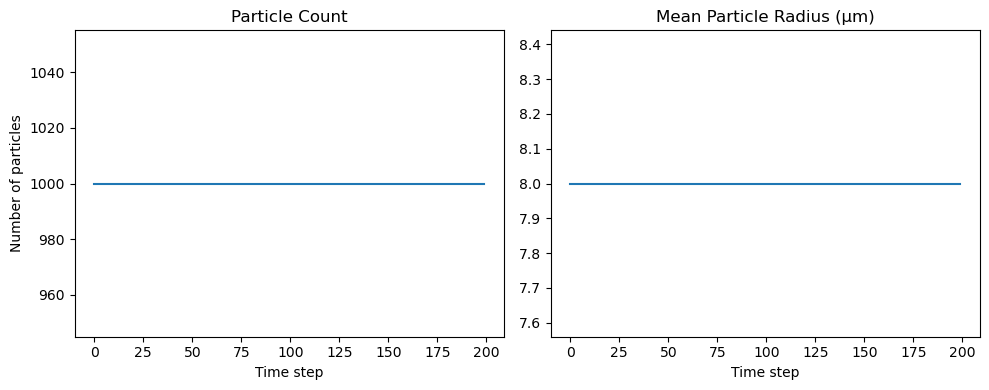

In [ ]:
## STEADY STATE MODEL      add sinking and particle injection to formula?

# define state variables?

# particle size classes


# IMPORTANT: the below is an AI-generated script for solving the Smoluchowski equation for particle size evolution, for learning only. No inclusion of stickiness, density or mass conservation 
# Please do not rely solely on this, only use it to learn and check against literature and supervisor and develop model

# ---------------------------
# PARAMETERS
# ---------------------------
N0 = 1000                      # initial number of particles
# need to add gradually increasing size bins

diameter_um = 16.0             # microns
radius = diameter_um / 2.0     # microns
dt = 1.0                       # time step
t_max = 200                    # number of steps

# Convert to meters for physics
radius_m = radius * 1e-6

# Shear rate (s^-1) for marine environment (approx)           ## will adapt so that there is one shear value above MLD and another below MLD, this might need to be included as W m2 or similar
surface_G = 10.0      # above MLD
deep_G = 1             # below MLD (pull from literature)     ## can only be implemented in the model run when it differentiates over depth?, not time

# Density / settling constants (simplified)
initial_fd = 2        # fractal dimension
initial_density = 1050  # particle density (kg/m^3)                     ## very approximate, will add to include fractal dimension
rho_f = 1025  # seawater density (kg/m^3)                     ## 
mu = 1e-3     # viscosity (Pa·s)
g = 9.81

# Does fractal dimension change by a set amount with every x increase in size?

# Stickiness
a = 0.5       # particles have a 50% chance of sticking after collision

# ---------------------------
# INITIAL PARTICLES
# Each particle has a "volume" and "radius"
# ---------------------------
volumes = np.ones(N0) * (4/3) * np.pi * radius_m**3           ## maybe this needs changing to cross-sectional area

# ---------------------------
# HELPER FUNCTIONS
# ---------------------------
def radius_from_volume(v):
    return (3 * v / (4 * np.pi)) ** (1/3)

def settling_velocity(r):
    # Stokes settling velocity
    return (2/9) * (rho_p - rho_f) * g * r**2 / mu

def jackson_kernel(r1, r2):
    """
    Approximate Jackson kernel combining:
    - shear collision
    - differential settling
    """
    # Shear term
    beta_shear = 1.3 * G * (r1 + r2)**3

    # Differential settling term
    w1 = settling_velocity(r1)
    w2 = settling_velocity(r2)
    beta_settle = np.pi * (r1 + r2)**2 * abs(w1 - w2)

    return beta_shear + beta_settle

# ---------------------------
# SIMULATION
# ---------------------------
particle_counts = []
mean_sizes = []

for t in range(t_max):
    N = len(volumes)
    if N < 2:
        break

    radii = radius_from_volume(volumes)

    # Random pair sampling
    i = np.random.randint(0, N, size=N)
    j = np.random.randint(0, N, size=N)

    new_volumes = []
    removed = set()

    for a, b in zip(i, j):
        if a == b or a in removed or b in removed:
            continue

        r1, r2 = radii[a], radii[b]
        beta = jackson_kernel(r1, r2)

        # Probability of aggregation
        p = beta * dt

        if np.random.rand() < p:
            # Aggregate particles
            new_vol = volumes[a] + volumes[b]
            new_volumes.append(new_vol)
            removed.add(a)
            removed.add(b)

    # Keep unmerged particles
    survivors = [volumes[k] for k in range(N) if k not in removed]
    volumes = np.array(survivors + new_volumes)

    # Track stats
    particle_counts.append(len(volumes))
    mean_sizes.append(np.mean(radius_from_volume(volumes)) * 1e6)  # µm

# ---------------------------
# PLOT RESULTS
# ---------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(particle_counts)
plt.title("Particle Count")
plt.xlabel("Time step")
plt.ylabel("Number of particles")

plt.subplot(1, 2, 2)
plt.plot(mean_sizes)
plt.title("Mean Particle Radius (µm)")
plt.xlabel("Time step")

plt.tight_layout()
plt.show()

# needs to have a diagnostic figure similar to the cross-sectional area plot below
# and likely one for checking mass conservation too, i.e. sum of all particle masses should remain constant


0     0.000000
1     0.046479
2     0.094902
3     0.142113
4     0.188369
5     0.237397
6     0.319526
7     0.383882
8     0.435328
9     0.484750
10    0.541372
11    0.649050
12    0.749478
13    0.849930
14    0.948622
15    1.047047
16    1.146877
17    1.243582
18    1.340328
19    1.436784
20    1.532932
21    1.635458
22    1.735508
23    1.836121
24    1.934855
25    2.033526
26    2.131334
27    2.234384
28    2.340553
29    2.444161
30    2.565112
31    2.838581
32    3.109800
33    3.369716
34    3.626037
35    3.879628
36    4.129298
37    4.373231
38    4.615954
39    4.855883
40    5.093185
41    5.331995
42    5.569084
43    5.804225
44    6.036186
45    6.268081
46    6.499011
47    6.729386
48    6.960365
49    7.189910
50    7.421418
51    7.654133
52    7.885459
53    8.116974
54    8.350295
55    8.587400
56    8.825087
57    9.063850
58    9.300567
59    9.536547
dtype: float64
Density Method: 20.0 Temp Method: 80.0


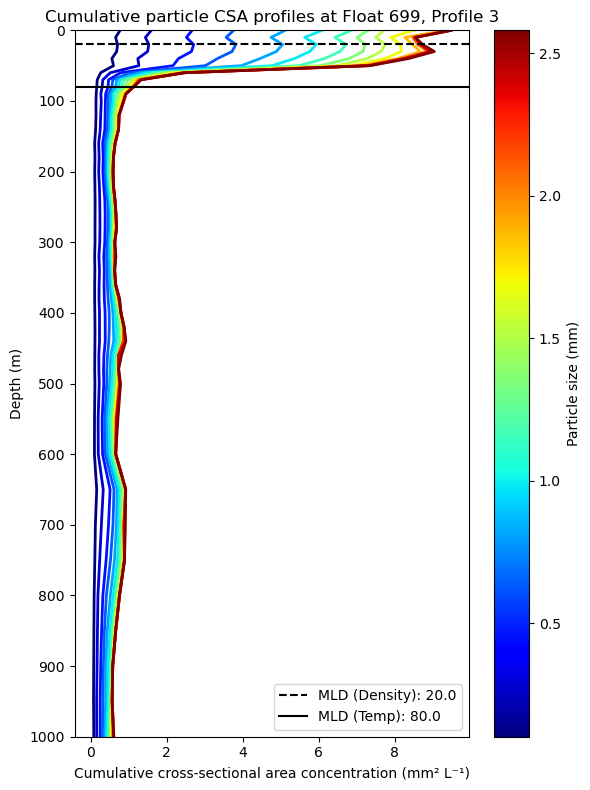

In [ ]:
## OBSERVATIONAL DATA DEPTH PROFILE (DIAGNOSTIC FIGURE) 

# pick profile that will be used as a diagnostic, maybe close to super station or something
# would need to calculate cross-sectional area of particles (method in notebook) for each size class
# then expand that over depth

mid_size = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="UVP_Float_Data").iloc[3:18, 16]     # (size_mid_um)
mid_size.drop_duplicates()
mid_size = mid_size.to_numpy(dtype=float)
mid_size[-1] = 2580

# Choose which float and profile to investigate
UVP6_float = 699
number = 3
profile = f699.p3  # here you can change the float profile, could probably tidy this up more so that when you write your variable name it updates UVP6_float and number automatically but not a good use of time

float_temp = temp_699["P3"]
float_sal = sal_699["P3"]

# Apply mid-size scaling
# shape = (n_sizes, n_depth)
concs = np.array([profile[s] for s in sizes], dtype=float)
circle_scale = np.pi * ((mid_size / 2) ** 2)  # calculate the cross-sectional area of a circle for each mid-size
cross_sectional_area = (concs * circle_scale[:, None]) / 1000000

## calculate mixed layer depth depending on profile
# extract temperature and density from relevant biogeochemical float data
# does that mean binning the temperature and density data to match the particle concentration depth bins?

import gsw
float_density = gsw.rho(float_sal, float_temp, depth) - 1000                  ## look at this as either a) how I calculated density or b) the pressure values I fed into it, is wrong, as density MLD seems to be very shallow
                                                                              ## additionally look at the binning of temperature and density, maybe add a secondary y axis for continous depth to assess more accurately

# reference values = first element
ref_density = float_density[0]
ref_temp = float_temp[0]

# find first index where threshold is met
density_diff = np.abs(float_density - ref_density)
temp_diff = np.abs(float_temp - ref_temp)
print(density_diff)

MLD_density_idx = np.where(density_diff >= 0.03)[0][0]
MLD_temp_idx = np.where(temp_diff >= 0.2)[0][0]

MLD_density = depth[MLD_density_idx] + 10      # correction for surface? As the array calculates 20 m as 10 m
MLD_temp = depth[MLD_temp_idx] + 10

print("Density Method:", MLD_density, 
      "Temp Method:", MLD_temp)


# Plotting Cumulative stack

fig, ax = plt.subplots(figsize=(6,8))

# cumulative sum across size bins
cumulative = np.cumsum(cross_sectional_area, axis=0)

# create a colour gradient
cmap = plt.cm.jet   # you can change this (plasma, turbo, etc.)
colors = cmap(np.linspace(0, 1, len(sizes/1000)))

# plot each cumulative boundary as a line
for i, s in enumerate(sizes):
    ax.plot(cumulative[i], depth,
            color=colors[i],
            linewidth=2)
    
ax.axhline(y = MLD_density, color="black", linestyle="--", label=f"MLD (Density): {MLD_density}")    # as straight line across
ax.axhline(y = MLD_temp, color="black", linestyle="-", label=f"MLD (Temp): {MLD_temp}")    # as straight line across

ax.set_xlabel("Cumulative cross-sectional area concentration (mm² L⁻¹)")
ax.set_ylabel("Depth (m)")
ax.set_ylim(0, 1000)
ax.set_yticks(np.linspace(0, 1000, 11))
ax.set_title(f"Cumulative particle CSA profiles at Float {UVP6_float}, Profile {number}")
ax.legend(loc="lower right")

# Colourbar
norm = plt.Normalize(vmin=min(sizes/1000), vmax=max(sizes/1000))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Particle size (mm)")

# Add Mixed Layer Depth? # mld = point at which temp at 10 m according to de Boyer Montegut et al, 2004

ax.invert_yaxis()

plt.tight_layout()
plt.show()
